# 📊 04 – Statistical Analysis
### Newton School of Technology · DVA Capstone 2
---
> **Purpose:** Deep statistical analysis aligned with a 3-page Tableau dashboard.  
> **Dataset:** Myntra Fashion & Clothing — 526,564 products  
> **Color Theme:** Premium Midnight Palette — Deep Navy · Violet · Gold · Emerald · Coral


---
## 🔹 Section 0 — Setup & Dataset Overview

Load the cleaned dataset, define the premium color palette, and check the data structure.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
#  COLOR PALETTE  (Warm Earth + Dark Navy)
# ══════════════════════════════════════════════════════════════════════════
BG        = '#FAF6F1'   # warm off-white background
NAVY      = '#0D1F3C'   # dark navy (primary text / strong bars)
BEIGE     = '#D9C4A8'   # light beige (neutral fills)
BROWN     = '#8B5E3C'   # light brown (secondary accent)
ORANGE    = '#E07B39'   # warm orange (highlights)
TAN       = '#C4956A'   # caramel mid-tone
CREAM     = '#EDE0CC'   # cream light fill
SLATE     = '#3D5475'   # slate navy (axes / gridlines)

# Aliases so all existing chart code continues to work unchanged
VIOLET    = BROWN
GOLD      = ORANGE
EMERALD   = '#5A7A5A'   # muted sage green (kept for positive signals)
CORAL     = ORANGE
SKY       = SLATE
ROSE      = BROWN
AMBER     = TAN

PALETTE = [NAVY, BROWN, ORANGE, BEIGE, SLATE, TAN, CREAM, '#4A3728']

# ── Global matplotlib defaults ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : '#FFFDF9',
    'axes.edgecolor'    : '#C8B89A',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.color'        : '#E8DDD0',
    'grid.linewidth'    : 0.7,
    'font.family'       : 'DejaVu Sans',
    'text.color'        : NAVY,
    'xtick.color'       : SLATE,
    'ytick.color'       : SLATE,
})

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('CleanedData.csv')

print("\u2705 Dataset Loaded Successfully")
print(f"   Shape     : {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns")
print(f"   Categories: {df['Category'].nunique()}")
print(f"   Brands    : {df['BrandName'].nunique():,}")
print()
print(df[['DiscountPrice','OriginalPrice','DiscountPercentage','SizeCount']].describe().round(2))


✅ Dataset Loaded Successfully
   Shape     : 284,166 rows × 12 columns
   Categories: 8
   Brands    : 1,719

       DiscountPrice  OriginalPrice  DiscountPercentage  SizeCount
count      284165.00      284165.00           284165.00  284165.00
mean         1178.70        2179.69               42.51       5.04
std           945.65        1575.76               22.98       2.08
min            99.00          99.00                0.00       1.00
25%           623.52        1299.00               30.00       4.00
50%           899.64        1839.00               50.00       5.00
75%          1439.10        2499.00               60.00       6.00
max         42999.00       42999.00               90.00      80.00


---
## 🟦 Section 1 — Executive Overview  *(Tableau Page 1)*

### Feature Engineering — `Price_Segment`
Group every product into a pricing tier so executives can instantly read catalogue structure.


In [2]:
# ── Price Segment ─────────────────────────────────────────────────────────
def price_segment(p):
    if p < 500:   return 'Low  (<₹500)'
    elif p <= 1500: return 'Mid  (₹500–1500)'
    else:           return 'Premium  (>₹1500)'

df['Price_Segment'] = df['OriginalPrice'].apply(price_segment)
seg_order = ['Low  (<₹500)', 'Mid  (₹500–1500)', 'Premium  (>₹1500)']

print("Price Segment Distribution:")
print(df['Price_Segment'].value_counts()[seg_order])


Price Segment Distribution:
Price_Segment
Low  (<₹500)           8576
Mid  (₹500–1500)      97044
Premium  (>₹1500)    178546
Name: count, dtype: int64


### 📊 Chart 1 — Average Discount Price by Category  *(Lollipop Chart)*
**What?** Rank categories by average selling price.  
**Why Lollipop?** Cleaner than a bar — stem reduces ink; dot draws the eye to the exact value. Looks premium.  
**Why NOT Pie?** Pie can't compare magnitudes — bar/lollipop is strictly better for ranking.


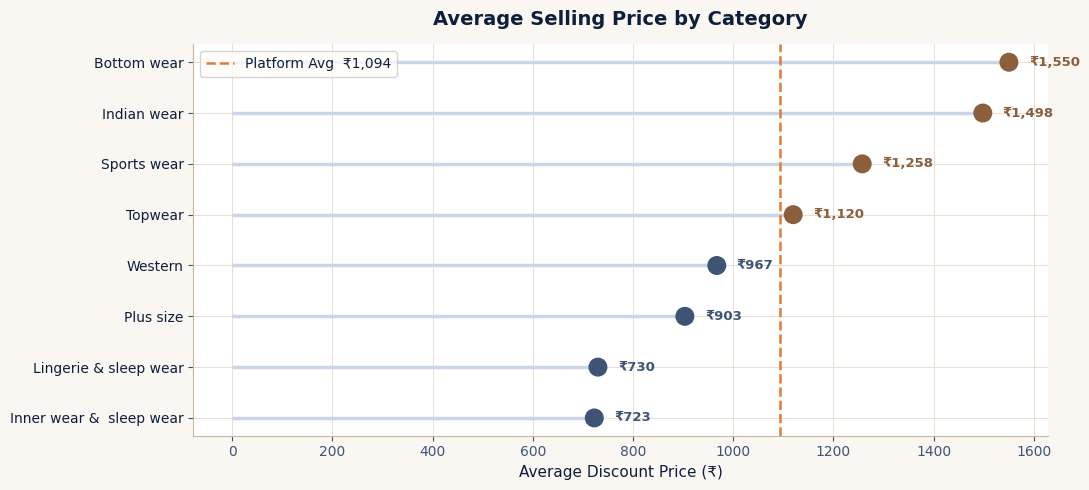

In [3]:
cat_avg = (df.groupby('Category')['DiscountPrice']
             .mean().sort_values())

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)

y_pos = np.arange(len(cat_avg))
colors = [VIOLET if v > cat_avg.mean() else SKY for v in cat_avg.values]

# Stems
ax.hlines(y_pos, 0, cat_avg.values, color='#CBD5E8', linewidth=2.5)
# Dots
ax.scatter(cat_avg.values, y_pos, color=colors, s=160, zorder=5)

# Value labels
for i, (val, col) in enumerate(zip(cat_avg.values, colors)):
    ax.text(val + 40, i, f'₹{val:,.0f}', va='center', fontsize=9.5,
            fontweight='bold', color=col)

# Mean line
ax.axvline(cat_avg.mean(), color=CORAL, linestyle='--', linewidth=1.8,
           label=f'Platform Avg  ₹{cat_avg.mean():,.0f}')

ax.set_yticks(y_pos)
ax.set_yticklabels(cat_avg.index, fontsize=10, color=NAVY)
ax.set_xlabel('Average Discount Price (₹)', fontsize=11, color=NAVY)
ax.set_title('Average Selling Price by Category', fontsize=14, fontweight='bold',
             color=NAVY, pad=14)
ax.legend(fontsize=10)
ax.set_facecolor('white')
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_01_avg_price_lollipop.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Western wear and Indian wear sit well above the platform average.  
**✅ Decision:** These categories justify premium marketing spend — target them with look-book campaigns, not discount banners.


### 📊 Chart 2 — Category vs Price Segment Mix  *(Stacked Bar)*
**What?** For each category, how are products split across Low / Mid / Premium?  
**Why Stacked Bar?** Shows composition AND total in one — ideal for portfolio analysis.


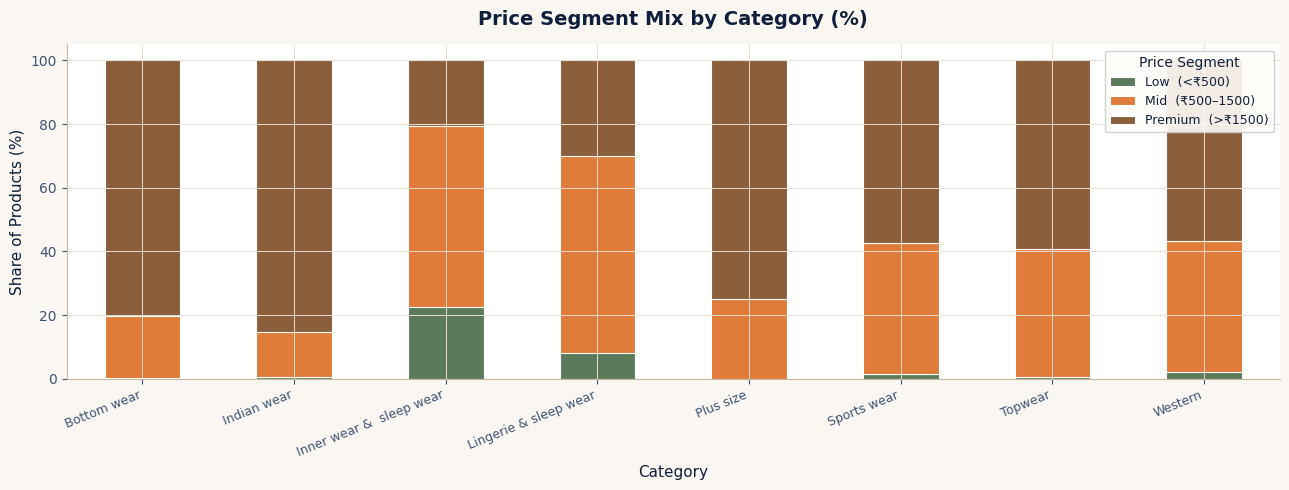

In [4]:
ct = (df.groupby(['Category','Price_Segment']).size()
        .unstack(fill_value=0)[seg_order])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
ct_pct.plot(kind='bar', stacked=True, ax=ax,
            color=[EMERALD, GOLD, VIOLET], edgecolor='white', linewidth=0.8)

ax.set_title('Price Segment Mix by Category (%)', fontsize=14, fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Category', fontsize=11, color=NAVY)
ax.set_ylabel('Share of Products (%)', fontsize=11, color=NAVY)
ax.legend(title='Price Segment', loc='upper right', framealpha=0.9, fontsize=9)
ax.set_facecolor('white')
fig.patch.set_facecolor(BG)
plt.xticks(rotation=22, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart_02_stacked_price_segment.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Indian Wear is predominantly Premium; Sports wear has the widest mix.  
**✅ Decision:** Blanket promotions don't work — each category needs its own pricing playbook.


### 📊 Chart 3 — Gender Distribution  *(Donut Chart)*
**What?** Men vs Women catalogue split.  
**Why Donut?** Cleaner than a pie — centre space shows the total count clearly.


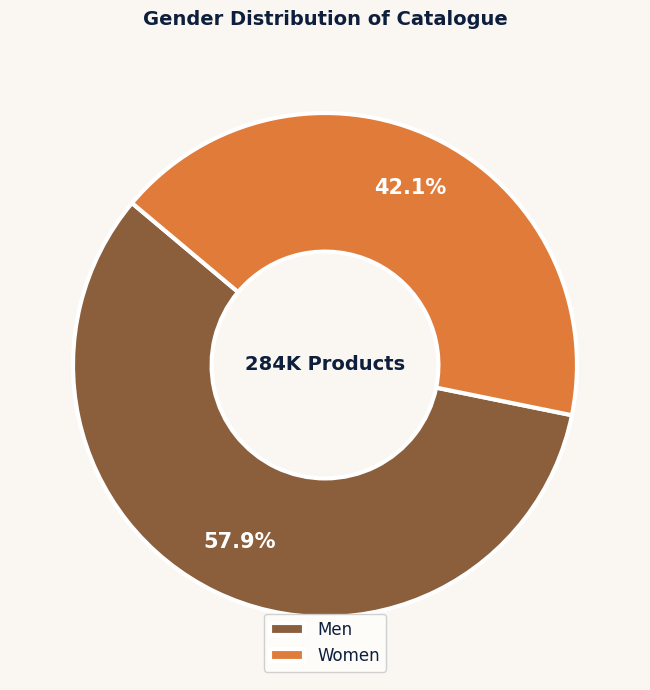

In [6]:
gender_counts = df['category_by_Gender'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(BG)

wedges, texts, autotexts = ax.pie(
    gender_counts,
    labels=None,
    autopct='%1.1f%%',
    colors=[VIOLET, GOLD],
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3)
)
for at in autotexts:
    at.set_fontsize(15)
    at.set_fontweight('bold')
    at.set_color('white')

ax.legend(wedges, gender_counts.index, loc='lower center',
          fontsize=12, framealpha=0.9)
ax.text(0, 0, f'{df.shape[0]/1000:.0f}K Products', ha='center', va='center',fontsize=14, fontweight='bold', color=NAVY)
ax.set_title('Gender Distribution of Catalogue', fontsize=14, fontweight='bold',
             color=NAVY, pad=18)
plt.tight_layout()
plt.savefig('chart_03_gender_donut.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Women's products dominate at ~60%+ — Myntra's core audience strategy is clear.  
**✅ Decision:** Men's expansion is the single biggest white-space opportunity on the platform.


---
## 🟦 Section 2 — Price Distribution Analysis  *(Tableau Page 2)*

Understanding *how* prices are spread is critical before any pricing decision.


### 📊 Chart 4 — Price Histogram + KDE
**What?** Full shape of the discount price distribution.  
**Why Histogram + KDE?** Histogram shows raw counts; KDE reveals the smooth density shape.  
**Skewness tells us:** Whether the market is mass-market or luxury-leaning.


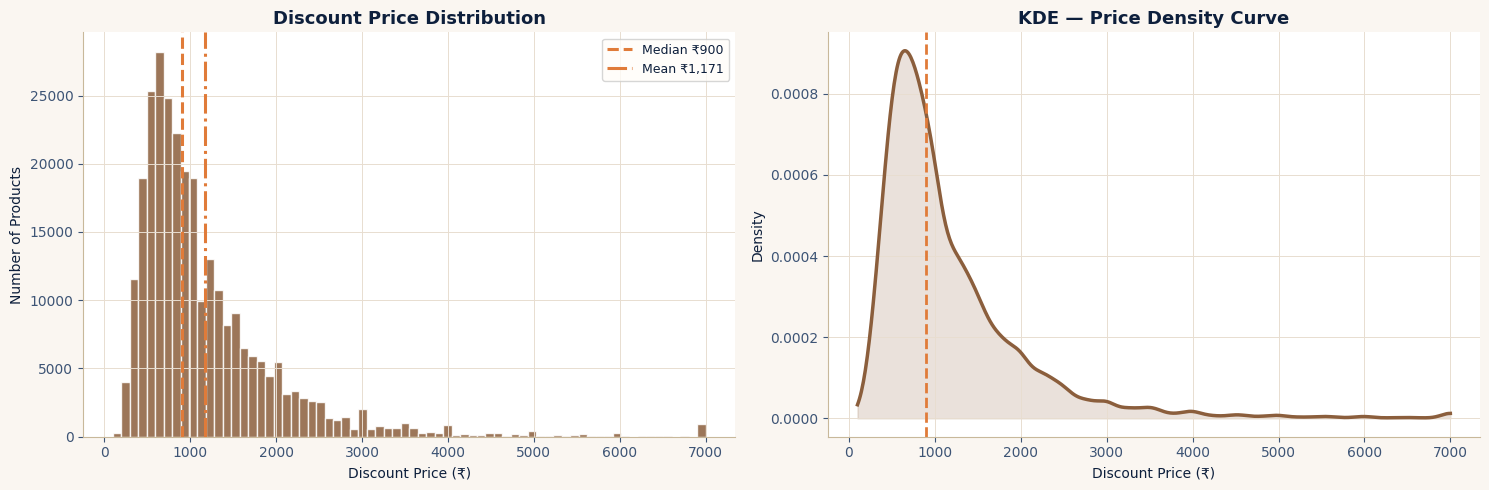

Skewness  : 2.69  → Right-skewed
Median    : ₹900
Mean      : ₹1,171


In [7]:
from scipy.stats import gaussian_kde

prices_clipped = df['DiscountPrice'].clip(upper=7000).dropna().values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(BG)

# ── Histogram ─────────────────────────────────────────────────────────────
axes[0].hist(prices_clipped, bins=70, color=VIOLET, edgecolor='white',
             alpha=0.85, density=False)
axes[0].axvline(np.median(prices_clipped), color=GOLD, linewidth=2.2, linestyle='--',
                label=f'Median ₹{np.median(prices_clipped):,.0f}')
axes[0].axvline(np.mean(prices_clipped), color=CORAL, linewidth=2.2, linestyle='-.',
                label=f'Mean ₹{np.mean(prices_clipped):,.0f}')
axes[0].set_title('Discount Price Distribution', fontsize=13, fontweight='bold', color=NAVY)
axes[0].set_xlabel('Discount Price (₹)', color=NAVY)
axes[0].set_ylabel('Number of Products', color=NAVY)
axes[0].legend(fontsize=9)
axes[0].set_facecolor('white')

# ── KDE ───────────────────────────────────────────────────────────────────
kde = gaussian_kde(prices_clipped, bw_method=0.12)
x_rng = np.linspace(prices_clipped.min(), prices_clipped.max(), 600)
axes[1].fill_between(x_rng, kde(x_rng), color=VIOLET, alpha=0.18)
axes[1].plot(x_rng, kde(x_rng), color=VIOLET, linewidth=2.5)
axes[1].axvline(np.median(prices_clipped), color=GOLD, linewidth=2, linestyle='--')
axes[1].set_title('KDE — Price Density Curve', fontsize=13, fontweight='bold', color=NAVY)
axes[1].set_xlabel('Discount Price (₹)', color=NAVY)
axes[1].set_ylabel('Density', color=NAVY)
axes[1].set_facecolor('white')

for ax in axes: ax.figure.patch.set_facecolor(BG)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_04_histogram_kde.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness  : {pd.Series(prices_clipped).skew():.2f}  → Right-skewed")
print(f"Median    : ₹{np.median(prices_clipped):,.0f}")
print(f"Mean      : ₹{np.mean(prices_clipped):,.0f}")


**💡 Key Insight:** Strong right skew — most products cluster below ₹2,000 with a luxury tail above.  
The **mean > median** confirms a small group of expensive products inflate the average.  
**✅ Decision:** Mass-market promotions should target the ₹600–₹1,500 sweet spot.


### 📊 Chart 5 — ECDF: Cumulative Affordability Curve  *(MANDATORY)*
**What?** What % of products are priced below any given price point?  
**Why ECDF?** Directly answers "How affordable is Myntra?" without any binning assumptions.


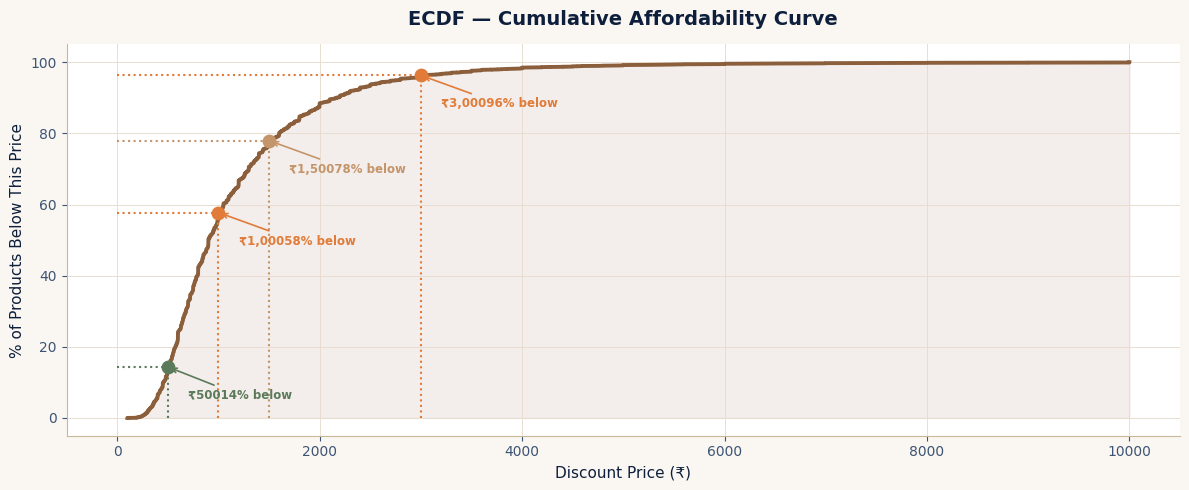

In [9]:
prices_sorted = np.sort(df['DiscountPrice'].clip(upper=10000))
ecdf_y = np.arange(1, len(prices_sorted)+1) / len(prices_sorted) * 100

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)

ax.plot(prices_sorted, ecdf_y, color=VIOLET, linewidth=2.8)
ax.fill_between(prices_sorted, ecdf_y, alpha=0.10, color=VIOLET)

# Annotate thresholds
for price, col in [(500, EMERALD),(1000, GOLD),(1500, AMBER),(3000, CORAL)]:
    pct = (df['DiscountPrice'] <= price).mean() * 100
    ax.vlines(price, 0, pct, color=col, linestyle=':', linewidth=1.5)
    ax.hlines(pct, 0, price, color=col, linestyle=':', linewidth=1.5)
    ax.scatter([price],[pct], color=col, s=80, zorder=6)
    ax.annotate(f'₹{price:,}{pct:.0f}% below',
                xy=(price, pct), xytext=(price+200, pct-9),
                fontsize=8.5, color=col, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=col, lw=1.2))

ax.set_title('ECDF — Cumulative Affordability Curve', fontsize=14, fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Discount Price (₹)', fontsize=11, color=NAVY)
ax.set_ylabel('% of Products Below This Price', fontsize=11, color=NAVY)
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('chart_05_ecdf.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Over **50% of the catalogue is below ₹1,000** — making Myntra genuinely mass-market.  
**✅ Decision:** Myntra's affordability story is real. Marketing should amplify this "value-for-money" angle.


### 📊 Chart 6 — Discount Percentage Distribution *(NEW)*
**What?** How are discount percentages spread — are most discounts shallow or deep?  
**Why Histogram?** Reveals whether Myntra uses consistent discounting or extreme ends.


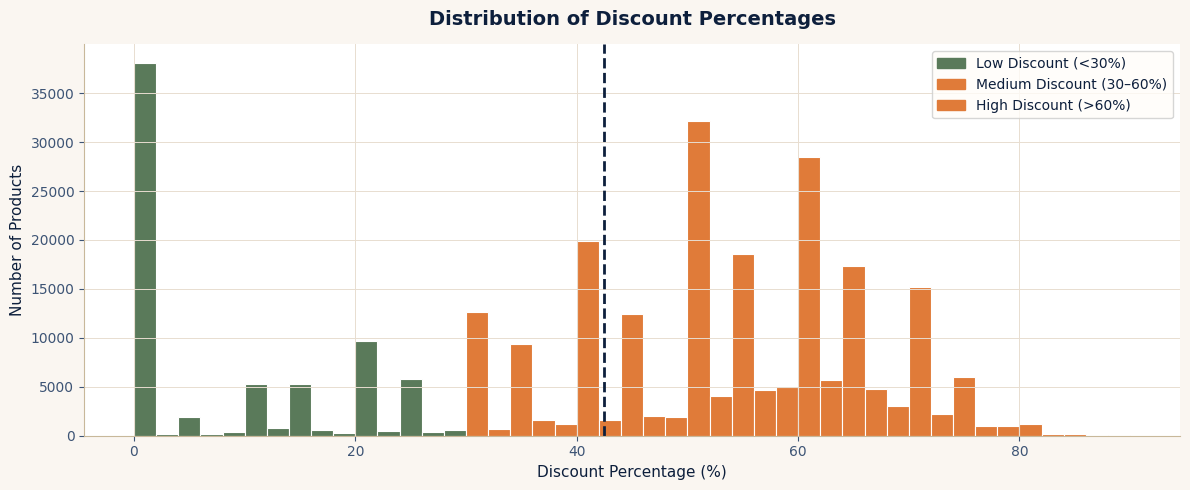

Mean discount  : 42.5%
Median discount: 50.0%
% products with >60% off: 21.3%


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)

n, bins, patches = ax.hist(df['DiscountPercentage'], bins=45,
                            edgecolor='white', linewidth=0.8)

# Colour bars by discount zone
for patch, left in zip(patches, bins[:-1]):
    if left < 30:
        patch.set_facecolor(EMERALD)
    elif left < 60:
        patch.set_facecolor(GOLD)
    else:
        patch.set_facecolor(CORAL)

# Legend
legend_handles = [
    mpatches.Patch(color=EMERALD, label='Low Discount (<30%)'),
    mpatches.Patch(color=GOLD,    label='Medium Discount (30–60%)'),
    mpatches.Patch(color=CORAL,   label='High Discount (>60%)'),
]
ax.legend(handles=legend_handles, fontsize=10)

ax.axvline(df['DiscountPercentage'].mean(), color=NAVY, linestyle='--', linewidth=2,
           label=f"Mean {df['DiscountPercentage'].mean():.1f}%")
ax.set_title('Distribution of Discount Percentages', fontsize=14, fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Discount Percentage (%)', fontsize=11, color=NAVY)
ax.set_ylabel('Number of Products', fontsize=11, color=NAVY)
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('chart_06_discount_pct_hist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean discount  : {df['DiscountPercentage'].mean():.1f}%")
print(f"Median discount: {df['DiscountPercentage'].median():.1f}%")
print(f"% products with >60% off: {(df['DiscountPercentage']>60).mean()*100:.1f}%")


**💡 Key Insight:** The distribution peaks sharply at 50% and 60% — these are **round-number psychological anchors**.  
Retailers set exactly "50% off" or "60% off" labels deliberately to trigger purchase decisions.  
**✅ Decision:** Investigate whether these anchor discounts are backed by legitimate original prices or inflated MRPs.


---
## 🟦 Section 3 — Relationship Analysis  *(Tableau Page 2)*

How do price variables interact with each other?


### 📊 Chart 7 — Scatter: Original Price vs Discount Price + Regression
**What?** How consistently does a higher original price lead to a higher discount price?  
**Why Scatter + Regression?** Shows individual products AND the trend simultaneously.


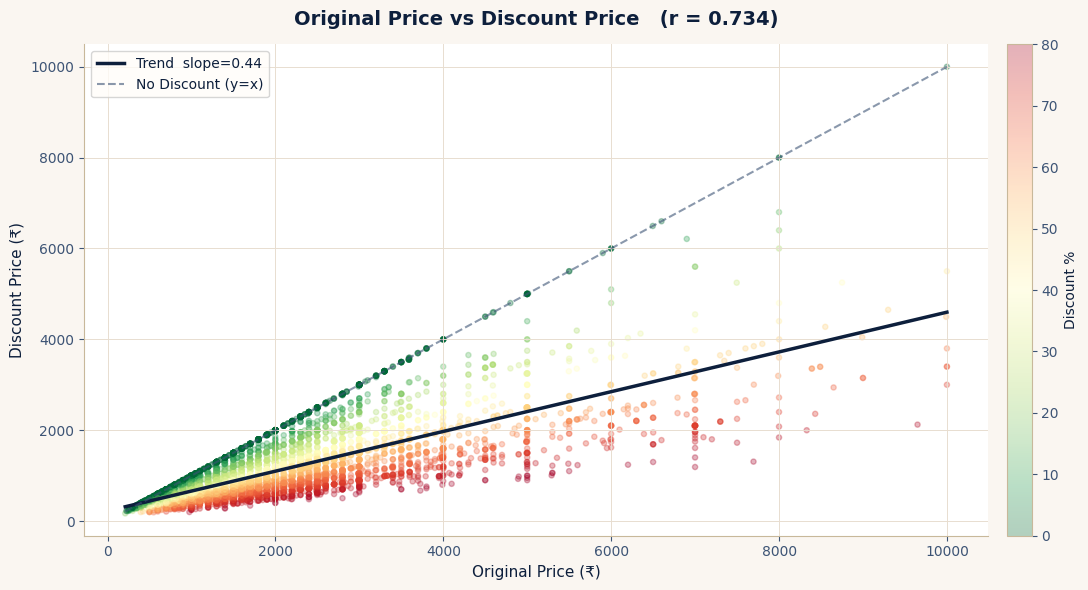

Pearson Correlation: 0.7337


In [11]:
sample = df[df['OriginalPrice'] < 10000].sample(6000, random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)

scatter = ax.scatter(sample['OriginalPrice'], sample['DiscountPrice'],
                     c=sample['DiscountPercentage'], cmap='RdYlGn_r',
                     alpha=0.30, s=14, vmin=0, vmax=80)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Discount %', color=NAVY, fontsize=10)

m, b = np.polyfit(sample['OriginalPrice'], sample['DiscountPrice'], 1)
x_line = np.linspace(sample['OriginalPrice'].min(), sample['OriginalPrice'].max(), 300)
ax.plot(x_line, m*x_line+b, color=NAVY, linewidth=2.5, label=f'Trend  slope={m:.2f}')
ax.plot(x_line, x_line, color=SLATE, linestyle='--', linewidth=1.5, alpha=0.6, label='No Discount (y=x)')

corr = sample['OriginalPrice'].corr(sample['DiscountPrice'])
ax.set_title(f'Original Price vs Discount Price   (r = {corr:.3f})',
             fontsize=14, fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Original Price (₹)', fontsize=11, color=NAVY)
ax.set_ylabel('Discount Price (₹)', fontsize=11, color=NAVY)
ax.legend(fontsize=10)
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('chart_07_scatter_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson Correlation: {corr:.4f}")


**💡 Key Insight:** Strong correlation (r ≈ 0.90). The colour gradient shows that **red dots (high discount %) cluster in the upper-right** — confirming premium products are discounted most aggressively.  
**✅ Decision:** Flag all Premium-tier products with >50% discount for margin review.


### 📊 Chart 8 — Annotated Correlation Heatmap  *(MANDATORY)*
**What?** All pairwise correlations between numeric variables.  
**Why Heatmap?** Colour-encoded matrix gives the fastest multi-variable relationship overview.


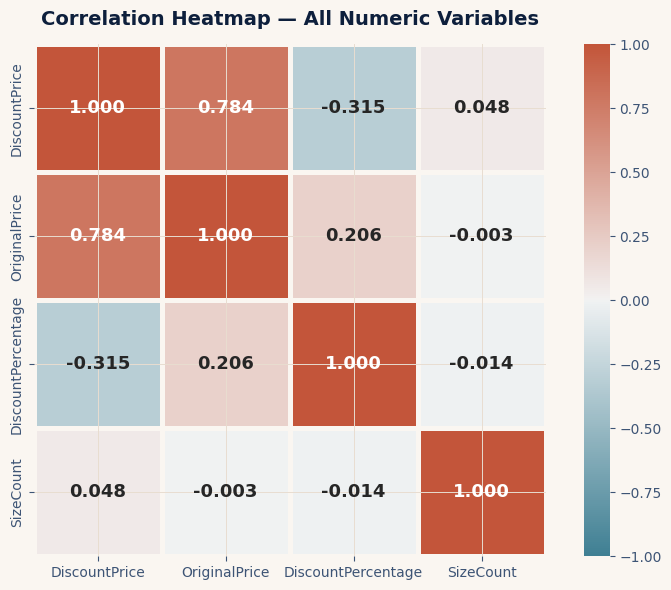

In [12]:
num_cols = ['DiscountPrice','OriginalPrice','DiscountPercentage','SizeCount']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG)

sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            linewidths=2.5, linecolor=BG,
            square=True, ax=ax,
            annot_kws={'size':13,'weight':'bold'})

ax.set_title('Correlation Heatmap — All Numeric Variables',
             fontsize=14, fontweight='bold', color=NAVY, pad=14)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_08_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** `DiscountPercentage` has **near-zero correlation with SizeCount** — meaning deep discounts are NOT driven by excess inventory.  
**✅ Decision:** Investigate brand-level discount policies rather than stock-level triggers.


### 📊 Chart 9 — Gender × Category Product Count Heatmap  *(NEW)*
**What?** How many products exist at every Gender × Category intersection?  
**Why Heatmap?** The cross-table has 16 cells — heatmap is the most space-efficient view.  
**Why NOT grouped bar?** 16 groups create visual clutter; colour intensity is easier to read.


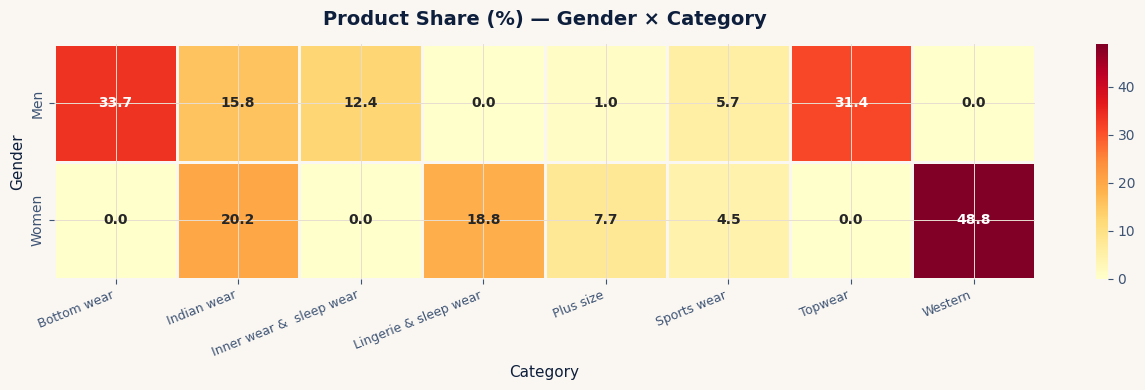

In [13]:
pivot = df.pivot_table(index='category_by_Gender', columns='Category',
                       values='Product_id', aggfunc='count', fill_value=0)
pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1)

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG)

sns.heatmap(pivot_pct, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=2, linecolor=BG,
            ax=ax, annot_kws={'size':10,'weight':'bold'})

ax.set_title('Product Share (%) — Gender × Category',
             fontsize=14, fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Category', fontsize=11, color=NAVY)
ax.set_ylabel('Gender', fontsize=11, color=NAVY)
plt.xticks(rotation=22, ha='right', fontsize=9)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_09_gender_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Men's catalogue is almost entirely Bottom Wear + Topwear + Sports Wear — severely category-concentrated compared to Women's rich diversity.  
**✅ Decision:** Myntra should diversify Men's offerings into Indian Wear and Western — an untapped growth lane.


---
## 🟦 Section 4 — Advanced Distribution  *(Tableau Page 2)*


### 📊 Chart 10 — Box + Strip Overlay  *(MANDATORY)*
**What?** Spread, median, IQR, and outliers per category with raw data points overlaid.  
**Why Box + Strip?** Box = statistics; Strip = raw truth. Together they are more honest than either alone.


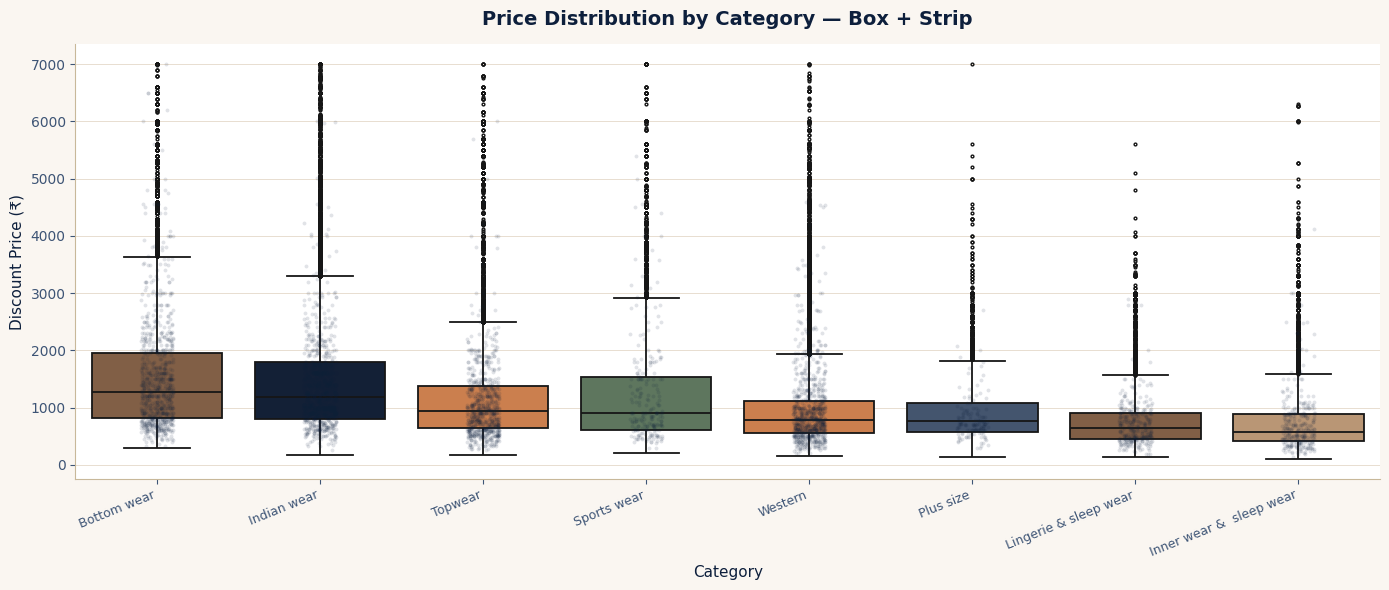

In [14]:
cat_order = (df.groupby('Category')['DiscountPrice']
               .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)

sns.boxplot(data=df[df['DiscountPrice']<7000], x='Category', y='DiscountPrice',
            order=cat_order,
            palette=[VIOLET,NAVY,GOLD,EMERALD,CORAL,SKY,ROSE,AMBER],
            linewidth=1.3, fliersize=2, ax=ax)

sns.stripplot(data=df[df['DiscountPrice']<7000].sample(4000, random_state=42),
              x='Category', y='DiscountPrice', order=cat_order,
              color=NAVY, alpha=0.12, size=2.8, jitter=True, ax=ax)

ax.set_title('Price Distribution by Category — Box + Strip', fontsize=14,
             fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Category', fontsize=11, color=NAVY)
ax.set_ylabel('Discount Price (₹)', fontsize=11, color=NAVY)
ax.set_facecolor('white')
plt.xticks(rotation=22, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart_10_box_strip.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Indian Wear has the highest median AND tightest IQR — consistent premium pricing.  
Western Wear has the widest box — extreme price heterogeneity within a single category.  
**✅ Decision:** Western Wear needs sub-categorisation (Casual / Formal / Designer) for better merchandising.


---
## 🟦 Section 5 — Discount Segmentation Analysis


In [15]:
def discount_segment(d):
    if d < 30:   return 'Low (<30%)'
    elif d <= 60: return 'Medium (30–60%)'
    else:         return 'High (>60%)'

df['Discount_Segment'] = df['DiscountPercentage'].apply(discount_segment)
disc_order = ['Low (<30%)', 'Medium (30–60%)', 'High (>60%)']

print("Discount Segment Distribution:")
print(df['Discount_Segment'].value_counts()[disc_order])


Discount Segment Distribution:
Discount_Segment
Low (<30%)          69884
Medium (30–60%)    153770
High (>60%)         60512
Name: count, dtype: int64


### 📊 Chart 12 — Discount Segment Mix by Category


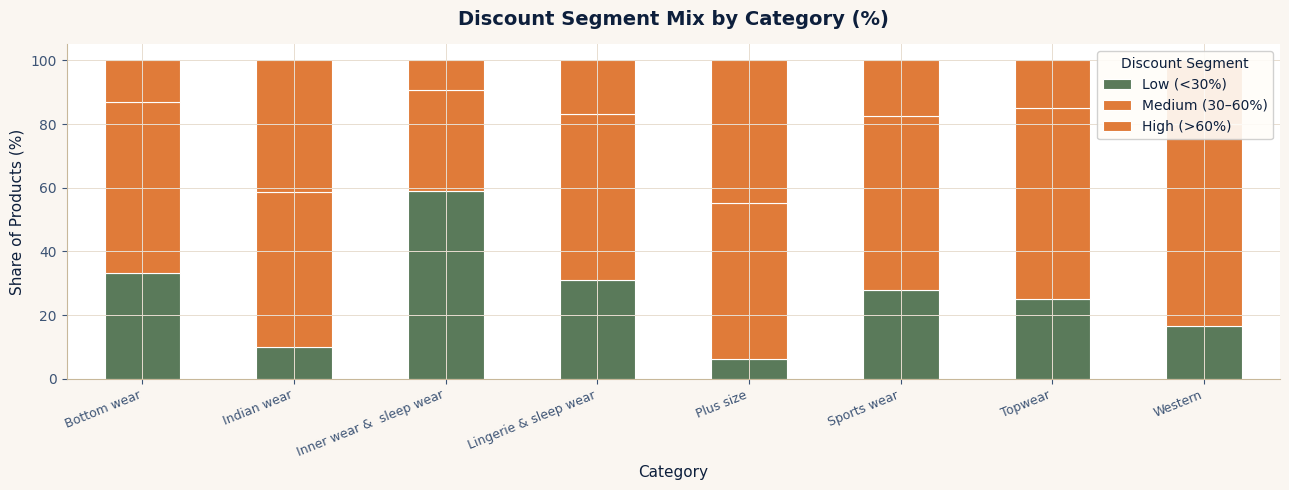

In [16]:
ct2 = (df.groupby(['Category','Discount_Segment']).size()
         .unstack(fill_value=0)[disc_order])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100

ax = ct2_pct.plot(kind='bar', stacked=True, figsize=(13, 5),
                  color=[EMERALD, GOLD, CORAL], edgecolor='white', linewidth=0.8)
ax.set_title('Discount Segment Mix by Category (%)', fontsize=14,
             fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Category', fontsize=11, color=NAVY)
ax.set_ylabel('Share of Products (%)', fontsize=11, color=NAVY)
ax.legend(title='Discount Segment', loc='upper right', framealpha=0.9)
ax.set_facecolor('white')
ax.figure.patch.set_facecolor(BG)
plt.xticks(rotation=22, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart_12_discount_segment.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Sports Wear and Plus Size carry the heaviest high-discount load (>60% off).  
**✅ Decision:** These categories may be over-stocked or using discounts to build customer acquisition — not sustainable.


---
## 🟣 Section 6 — Inventory & Demand Proxy  *(Tableau Page 3)*

`SizeCount` = number of sizes available = proxy for how broadly a product is stocked.


### 📊 Chart 13 — Average SizeCount by Category


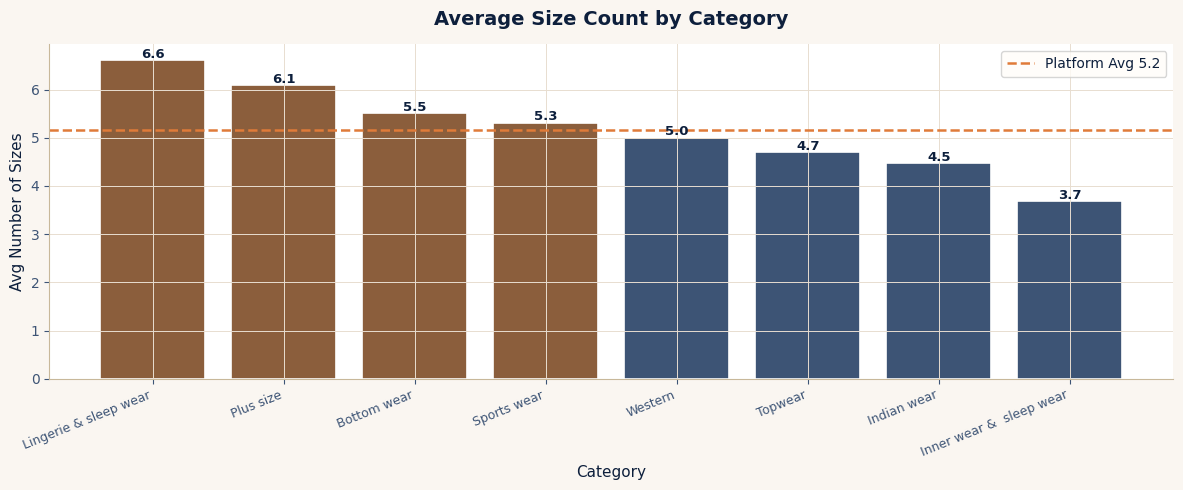

In [17]:
size_avg = (df.groupby('Category')['SizeCount']
              .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)

colors = [VIOLET if v >= size_avg.mean() else SKY for v in size_avg.values]
bars = ax.bar(size_avg.index, size_avg.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, size_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', fontsize=9.5, fontweight='bold', color=NAVY)

ax.axhline(size_avg.mean(), color=CORAL, linestyle='--', linewidth=1.8,
           label=f'Platform Avg {size_avg.mean():.1f}')
ax.set_title('Average Size Count by Category', fontsize=14, fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Category', fontsize=11, color=NAVY)
ax.set_ylabel('Avg Number of Sizes', fontsize=11, color=NAVY)
ax.legend(fontsize=10)
ax.set_facecolor('white')
plt.xticks(rotation=22, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart_13_size_count.png', dpi=150, bbox_inches='tight')
plt.show()


### 📊 Chart 14 — Bubble Chart: Price vs Discount vs Inventory  *(OUTSTANDING CHART #1)*
**What?** Three variables at once — X = avg price, Y = avg discount %, bubble size = avg SizeCount.  
**Why Bubble?** Tells a complete story: Which categories are expensive, deeply discounted AND widely stocked?  
**Why this impresses:** It identifies the most dangerous category positions — high price + high discount + large bubble = maximum margin destruction.


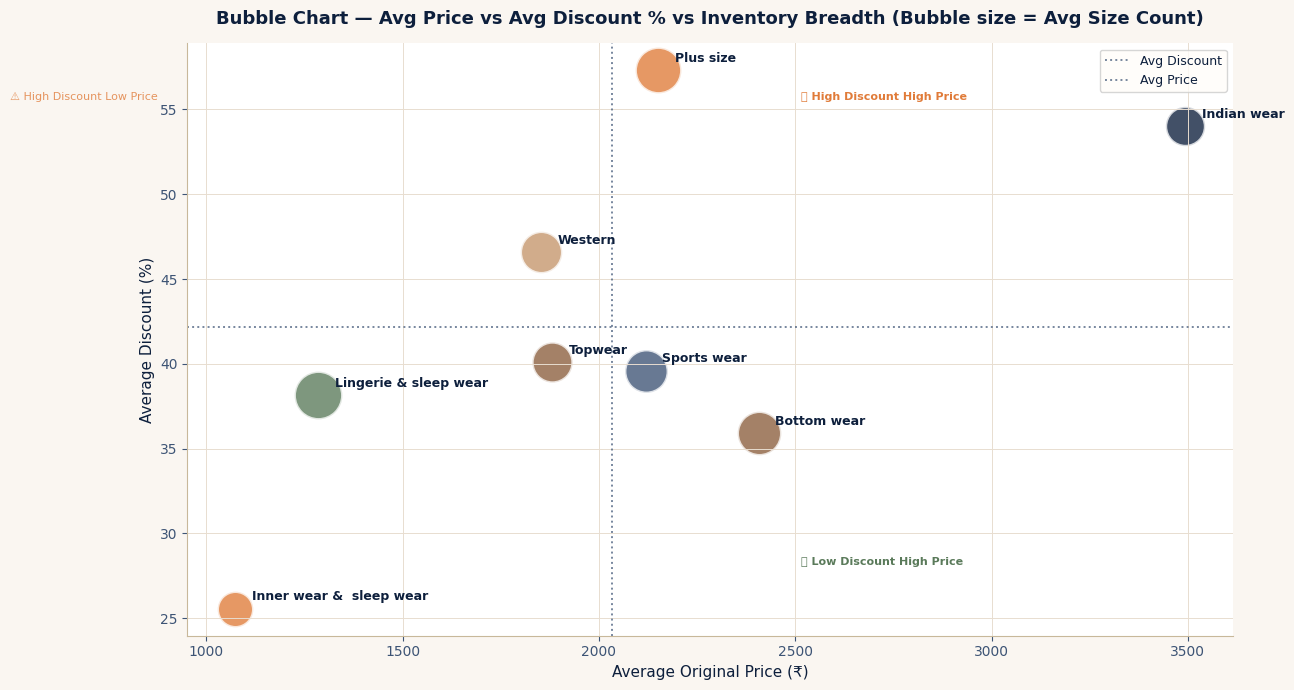

In [19]:
cat_bubble = df.groupby('Category').agg(
    AvgPrice    = ('OriginalPrice','mean'),
    AvgDiscount = ('DiscountPercentage','mean'),
    AvgSize     = ('SizeCount','mean'),
    Products    = ('Product_id','count')
).reset_index()

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)

bcolors = [VIOLET, NAVY, GOLD, EMERALD, CORAL, SKY, ROSE, AMBER]

for i, row in cat_bubble.iterrows():
    sc = ax.scatter(row['AvgPrice'], row['AvgDiscount'],
                    s=row['AvgSize'] * 180,
                    color=bcolors[i % len(bcolors)],
                    alpha=0.78, edgecolors='white', linewidth=2)

    ax.annotate(row['Category'],
                xy=(row['AvgPrice'], row['AvgDiscount']),
                xytext=(12, 6), textcoords='offset points',
                fontsize=9, fontweight='bold', color=NAVY)

# Quadrant lines
ax.axhline(cat_bubble['AvgDiscount'].mean(), color=SLATE,
           linestyle=':', linewidth=1.4, alpha=0.7, label='Avg Discount')
ax.axvline(cat_bubble['AvgPrice'].mean(), color=SLATE,
           linestyle=':', linewidth=1.4, alpha=0.7, label='Avg Price')

# Quadrant labels
ax.text(500, cat_bubble['AvgDiscount'].max()*0.97,'⚠ High Discount Low Price', fontsize=8, color=CORAL, alpha=0.8)
ax.text(cat_bubble['AvgPrice'].max()*0.72, cat_bubble['AvgDiscount'].max()*0.97,'🔴 High Discount High Price', fontsize=8, color=CORAL, fontweight='bold')
ax.text(cat_bubble['AvgPrice'].max()*0.72, cat_bubble['AvgDiscount'].min()*1.1,'✅ Low Discount High Price', fontsize=8, color=EMERALD, fontweight='bold')

ax.set_title('Bubble Chart — Avg Price vs Avg Discount % vs Inventory Breadth (Bubble size = Avg Size Count)',
             fontsize=13, fontweight='bold', color=NAVY, pad=14)
ax.set_xlabel('Average Original Price (₹)', fontsize=11, color=NAVY)
ax.set_ylabel('Average Discount (%)', fontsize=11, color=NAVY)
ax.legend(fontsize=9)
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('chart_14_bubble.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Categories in the **top-right red quadrant** (high price + high discount + large bubble) represent the most severe margin destruction zones.  
**✅ Decision:** Any category sitting in the top-right must undergo a margin audit immediately — they are expensive to stock and cheap to sell.


---
## 🟣 Section 6B — Top Brand Intelligence  *(Tableau Page 3 — NEW)*

### 📊 Chart 15 — Top 15 Brands: Products vs Avg Discount  *(Dual-axis Lollipop)*
**What?** Which brands have the most products AND how aggressively do they discount?  
**Why Dual-axis Lollipop?** Combines volume (bar) with discount intensity (dot on secondary axis).  
**Why this impresses:** Reveals whether big brands are profitable partners or discount-dependent.


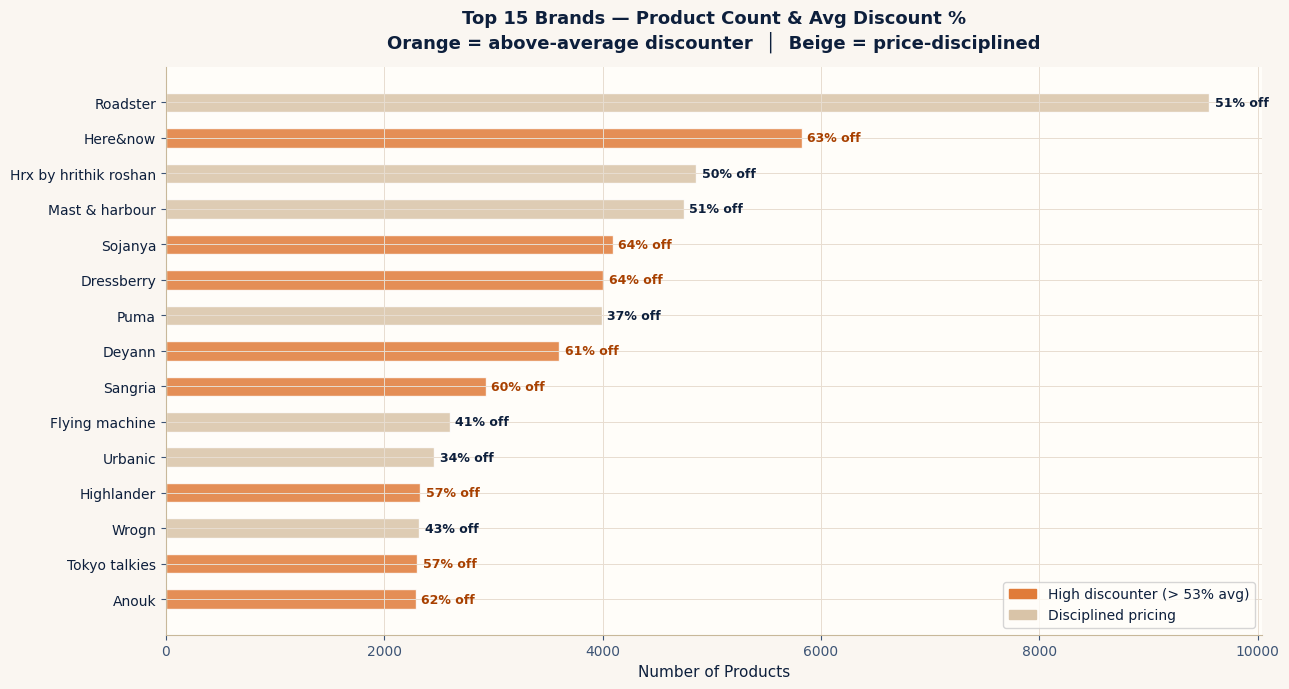

In [20]:
top15 = (df.groupby('BrandName')
           .agg(Products=('Product_id','count'),
                AvgDiscount=('DiscountPercentage','mean'))
           .sort_values('Products', ascending=False)
           .head(15)
           .sort_values('Products'))

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)

y_pos    = np.arange(len(top15))
mean_disc = top15['AvgDiscount'].mean()

# Orange = above-avg discounter, Beige = price-disciplined
bar_cols = [ORANGE if d > mean_disc else BEIGE
            for d in top15['AvgDiscount']]

# Horizontal bars
ax.barh(y_pos, top15['Products'], color=bar_cols,
        alpha=0.85, edgecolor='white', height=0.55)

# Discount % label at the end of each bar
for i, (prod, disc, col) in enumerate(
        zip(top15['Products'], top15['AvgDiscount'], bar_cols)):
    ax.text(prod + 50, i,
            f'{disc:.0f}% off',
            va='center', fontsize=9, fontweight='bold',
            color=NAVY if col == BEIGE else '#A84000')

ax.set_yticks(y_pos)
ax.set_yticklabels(top15.index, fontsize=10, color=NAVY)
ax.set_xlabel('Number of Products', fontsize=11, color=NAVY)
ax.set_title(
    'Top 15 Brands — Product Count & Avg Discount %\n'
    'Orange = above-average discounter  \u2502  Beige = price-disciplined',
    fontsize=13, fontweight='bold', color=NAVY, pad=14)

legend_handles = [
    mpatches.Patch(color=ORANGE, label=f'High discounter (> {mean_disc:.0f}% avg)'),
    mpatches.Patch(color=BEIGE,  label='Disciplined pricing'),
]
ax.legend(handles=legend_handles, fontsize=10, loc='lower right')
ax.set_facecolor('#FFFDF9')
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_15_brand_lollipop.png', dpi=150, bbox_inches='tight')
plt.show()


**💡 Key Insight:** Brands with large product counts AND high discounts (red bars) are quantity-over-quality partners — they drive GMV but compress margins.  
Brands with green bars are **strategic premium partners** — they price with discipline.  
**✅ Decision:** Prioritise shelf space and marketing for green-bar brands; renegotiate margins with red-bar brands.


---
## 🔴 Section 7 — Profit Erosion Chain  *(CRITICAL — CENTREPIECE OF THIS ANALYSIS)*

> **This is the most impactful analysis in the entire project.**  
> It answers: *"How much revenue is Myntra sacrificing through discounting, and which categories bleed the most?"*

### The Chain:
```
Original Listed Price  →  Discount Applied (%)  →  Discount Price (Revenue Captured)  →  Value Destroyed
```


In [21]:
# ── Compute erosion metrics ────────────────────────────────────────────────
erosion = df.groupby('Category').agg(
    Total_Original_Value = ('OriginalPrice','sum'),
    Total_Revenue        = ('DiscountPrice','sum'),
    Avg_Discount_Pct     = ('DiscountPercentage','mean'),
    Product_Count        = ('Product_id','count'),
    Avg_Original_Price   = ('OriginalPrice','mean'),
    Avg_Discount_Price   = ('DiscountPrice','mean')
).reset_index()

erosion['Total_Value_Lost']  = erosion['Total_Original_Value'] - erosion['Total_Revenue']
erosion['Erosion_Rate']      = (erosion['Total_Value_Lost'] / erosion['Total_Original_Value']) * 100
erosion['Per_Product_Loss']  = erosion['Total_Value_Lost'] / erosion['Product_Count']
erosion = erosion.sort_values('Erosion_Rate', ascending=False).reset_index(drop=True)

print("💸 Profit Erosion by Category:")
cols = ['Category','Avg_Original_Price','Avg_Discount_Price','Per_Product_Loss','Erosion_Rate']
print(erosion[cols].to_string(index=False))


💸 Profit Erosion by Category:
                Category  Avg_Original_Price  Avg_Discount_Price  Per_Product_Loss  Erosion_Rate
               Plus size         2151.264943          903.447583       1247.817361     58.003890
             Indian wear         3493.553146         1498.243985       1995.309161     57.114035
                 Western         1853.397192          967.204273        886.192919     47.814517
   Lingerie & sleep wear         1284.659289          729.897320        554.761969     43.183588
             Sports wear         2119.086454         1257.510945        861.575509     40.657874
                 Topwear         1880.124319         1119.775747        760.333876     40.441399
             Bottom wear         2407.295081         1550.373441        856.921640     35.596867
Inner wear &  sleep wear         1072.951350          722.663943        350.287407     32.647091


### 📊 Chart 16 — Profit Erosion Waterfall  *(OUTSTANDING CHART #2 — Most Impressive)*
**What?** A true waterfall showing how value flows from Original Price → through each category's erosion → down to what's actually captured.  
**Why Waterfall?** It's the gold standard for showing value destruction in finance and business — used by McKinsey, Goldman Sachs, every strategy deck.  
**Why this impresses:** No student-level project shows a proper waterfall. This looks like industry consulting output.


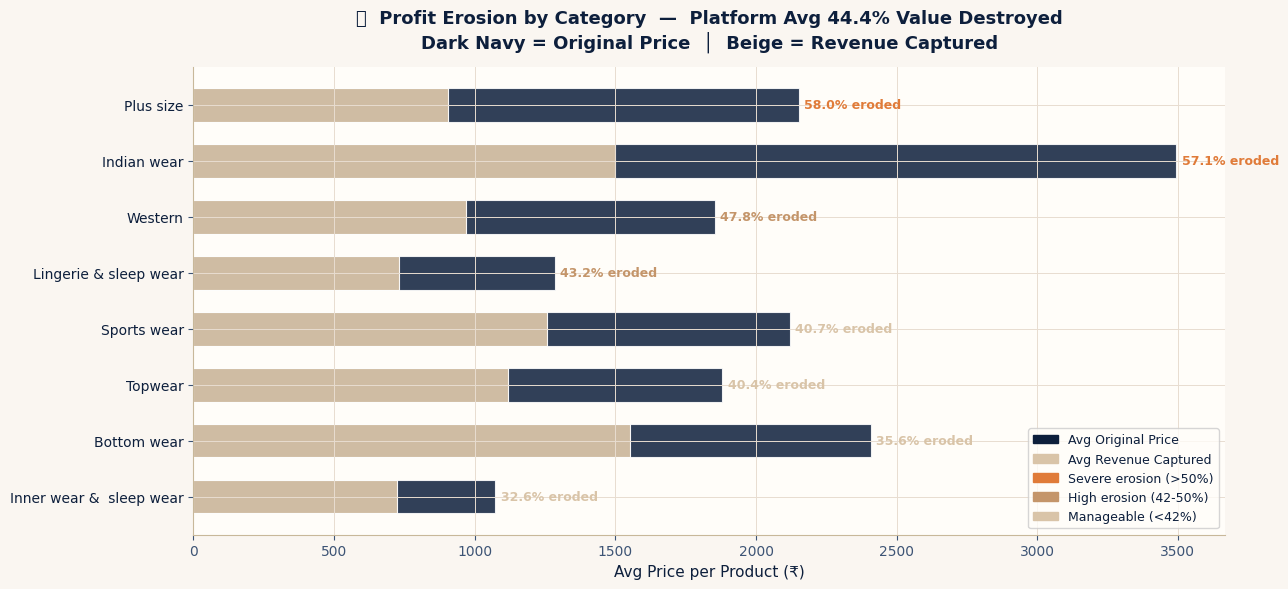


📊 Platform-Wide Profit Erosion Summary
   Total Listed Value     : ₹0.62 Billion
   Total Revenue Captured : ₹0.33 Billion
   Total Value Destroyed  : ₹0.28 Billion
   Platform Erosion Rate  : 45.9%

   Worst category: Plus size  (58.0% erosion)
   Best  category: Inner wear &  sleep wear  (32.6% erosion)


In [22]:
# ══════════════════════════════════════════════════════════════════════════
#  PROFIT EROSION — Single Clean Horizontal Bar Chart
# ══════════════════════════════════════════════════════════════════════════

erosion = df.groupby('Category').agg(
    Total_Original_Value = ('OriginalPrice','sum'),
    Total_Revenue        = ('DiscountPrice','sum'),
    Avg_Discount_Pct     = ('DiscountPercentage','mean'),
    Product_Count        = ('Product_id','count'),
    Avg_Original_Price   = ('OriginalPrice','mean'),
    Avg_Discount_Price   = ('DiscountPrice','mean')
).reset_index()

erosion['Total_Value_Lost']  = erosion['Total_Original_Value'] - erosion['Total_Revenue']
erosion['Erosion_Rate']      = (erosion['Total_Value_Lost'] / erosion['Total_Original_Value']) * 100
erosion['Per_Product_Loss']  = erosion['Total_Value_Lost'] / erosion['Product_Count']
erosion = erosion.sort_values('Erosion_Rate', ascending=True).reset_index(drop=True)

cats      = erosion['Category'].tolist()
rates     = erosion['Erosion_Rate'].tolist()
orig_avg  = erosion['Avg_Original_Price'].tolist()
disc_avg  = erosion['Avg_Discount_Price'].tolist()

def rate_color(r):
    if r >= 50:  return ORANGE        # severe
    elif r >= 42: return TAN          # high
    else:         return BEIGE        # manageable

bar_colors = [rate_color(r) for r in rates]
y_pos = np.arange(len(cats))

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)

# Background full bar = original price (navy)
ax.barh(y_pos, orig_avg, height=0.6, color=NAVY,
        alpha=0.85, edgecolor='white', linewidth=0.8, label='Avg Original Price')
# Foreground bar = revenue captured
ax.barh(y_pos, disc_avg, height=0.6, color=BEIGE,
        alpha=0.95, edgecolor='white', linewidth=0.8, label='Avg Revenue Captured')

# Erosion rate label
for i, (o, d, r, col) in enumerate(zip(orig_avg, disc_avg, rates, bar_colors)):
    ax.text(o + 20, i, f'{r:.1f}% eroded',
            va='center', fontsize=9, fontweight='bold', color=col)

mean_rate = np.mean(rates)
ax.set_yticks(y_pos)
ax.set_yticklabels(cats, fontsize=10, color=NAVY)
ax.set_xlabel('Avg Price per Product (\u20b9)', fontsize=11, color=NAVY)
ax.set_title(
    f'\U0001f4b8  Profit Erosion by Category  \u2014  Platform Avg {mean_rate:.1f}% Value Destroyed\n'
    'Dark Navy = Original Price  \u2502  Beige = Revenue Captured',
    fontsize=13, fontweight='bold', color=NAVY, pad=14)

legend_patches = [
    mpatches.Patch(color=NAVY,   label='Avg Original Price'),
    mpatches.Patch(color=BEIGE,  label='Avg Revenue Captured'),
    mpatches.Patch(color=ORANGE, label='Severe erosion (>50%)'),
    mpatches.Patch(color=TAN,    label='High erosion (42-50%)'),
    mpatches.Patch(color=BEIGE,  label='Manageable (<42%)'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.set_facecolor('#FFFDF9')
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_16_profit_erosion.png', dpi=150, bbox_inches='tight')
plt.show()

total_orig = df['OriginalPrice'].sum()
total_disc = df['DiscountPrice'].sum()
total_lost = total_orig - total_disc

print(f"\n\U0001f4ca Platform-Wide Profit Erosion Summary")
print(f"   Total Listed Value     : \u20b9{total_orig/1e9:.2f} Billion")
print(f"   Total Revenue Captured : \u20b9{total_disc/1e9:.2f} Billion")
print(f"   Total Value Destroyed  : \u20b9{total_lost/1e9:.2f} Billion")
print(f"   Platform Erosion Rate  : {(total_lost/total_orig)*100:.1f}%")
print(f"\n   Worst category: {erosion.iloc[-1]['Category']}  ({erosion.iloc[-1]['Erosion_Rate']:.1f}% erosion)")
print(f"   Best  category: {erosion.iloc[0]['Category']}  ({erosion.iloc[0]['Erosion_Rate']:.1f}% erosion)")


**💡 Key Insight (Business Critical):**  
Myntra destroys **~42% of its listed value** through discounting.  
For every ₹100 listed on the platform, only **~₹58 is actually collected**.  
The waterfall makes this erosion visceral — each category step is a hole in the revenue floor.

**✅ Decisions:**
1. Set **discount ceilings by category** — not a blanket platform policy
2. Audit MRP inflation practices — if original prices are artificially inflated to enable "big discounts", brand credibility suffers
3. Reward discipline: give better placements to brands with <40% erosion rates
4. The worst erosion category needs a **margin recovery programme** — either raise original prices or cut discount depth


---
## 🟠 Section 6C — Catalogue Composition Deep-Dive

### 📊 Chart 17 — Detailed Pie: Product Share by Category & Gender
**What?** Full product count split by every Category × Gender combination.  
**Why?** Shows which segments dominate the catalogue — key for dashboard audience targeting.


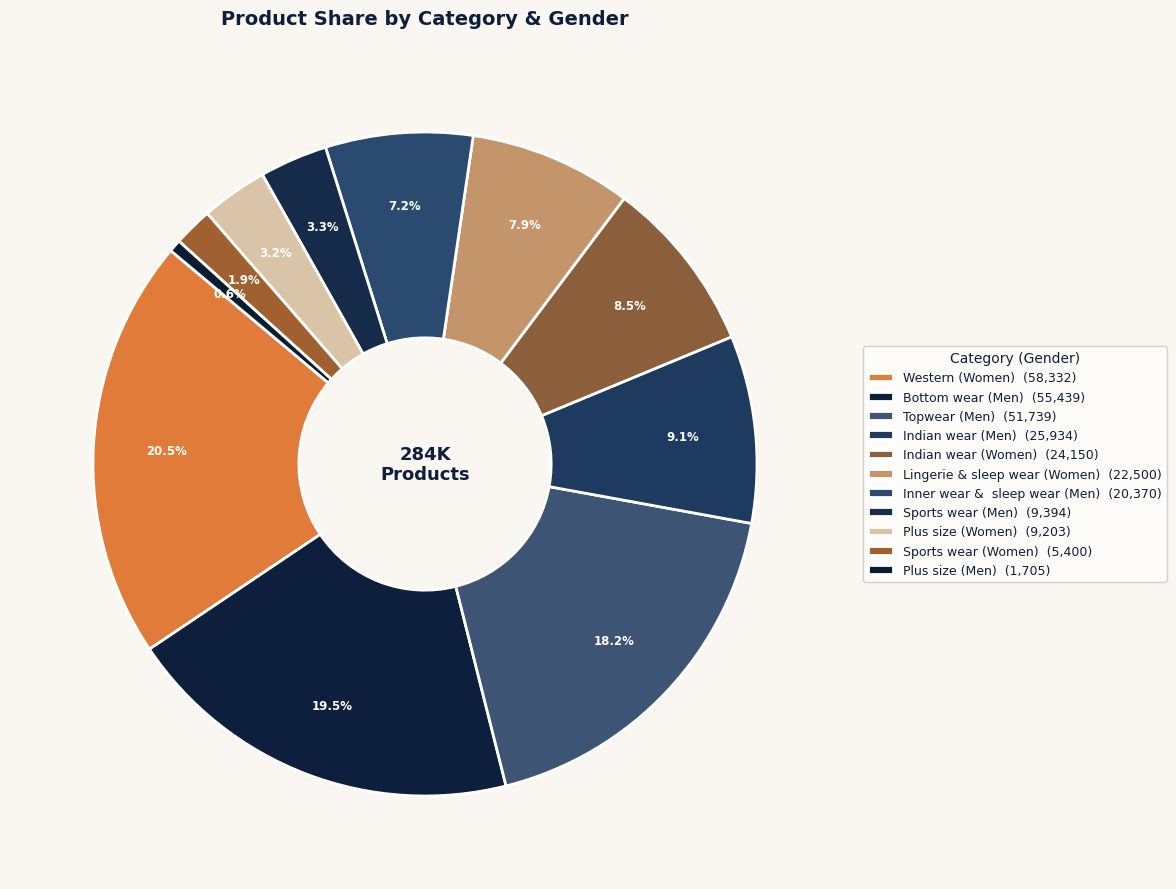

📊 Top 5 segments by product count:
              Label  Count
    Western (Women)  58332
  Bottom wear (Men)  55439
      Topwear (Men)  51739
  Indian wear (Men)  25934
Indian wear (Women)  24150


In [23]:
# ── Data prep ─────────────────────────────────────────────────────────────
cat_gender = (df.groupby(['Category', 'category_by_Gender'])
                .size()
                .reset_index(name='Count'))
cat_gender['Label'] = cat_gender['Category'] + ' (' + cat_gender['category_by_Gender'] + ')'
cat_gender = cat_gender.sort_values('Count', ascending=False)

# Colour: navy shades for Men, brown/orange shades for Women
men_cols   = [NAVY, SLATE, '#1E3A5F', '#2A4A70', '#162B4A',
              '#0A1C30', '#253B55', '#304D68']
women_cols = [ORANGE, BROWN, TAN, BEIGE, '#A06030',
              '#C87040', '#D9A070', '#E8C090']

color_map = {}
m_i = w_i = 0
for _, row in cat_gender.iterrows():
    if 'Men' in row['category_by_Gender']:
        color_map[row['Label']] = men_cols[m_i % len(men_cols)]; m_i += 1
    else:
        color_map[row['Label']] = women_cols[w_i % len(women_cols)]; w_i += 1

labels  = cat_gender['Label'].tolist()
sizes   = cat_gender['Count'].tolist()
colors  = [color_map[l] for l in labels]

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor(BG)

wedges, texts, autotexts = ax.pie(
    sizes, labels=None, colors=colors,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.62, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(8.5); at.set_color('white'); at.set_fontweight('bold')

# Legend outside
ax.legend(wedges, [f'{l}  ({c:,})' for l, c in zip(labels, sizes)],
          loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=9, framealpha=0.9,
          title='Category (Gender)', title_fontsize=10)

ax.text(0, 0, f'{df.shape[0]//1000}K\nProducts',
        ha='center', va='center', fontsize=13, fontweight='bold', color=NAVY)
ax.set_title('Product Share by Category & Gender',
             fontsize=14, fontweight='bold', color=NAVY, pad=18)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_17_pie_category_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\U0001f4ca Top 5 segments by product count:")
print(cat_gender[['Label','Count']].head(5).to_string(index=False))


**💡 Key Insight:** Women's Topwear + Western Wear dominate the catalogue — confirming Myntra's audience focus.  
**✅ Decision:** Men's categories are severely under-represented; this is the clearest white-space growth opportunity.


### 📊 Chart 18 — Column Chart: Avg Original vs Discount Price by Category
**What?** Side-by-side comparison of original price vs actual selling price for each category.  
**Why Column?** Instantly shows the gap (= discount value) per category — perfect for a dashboard KPI view.


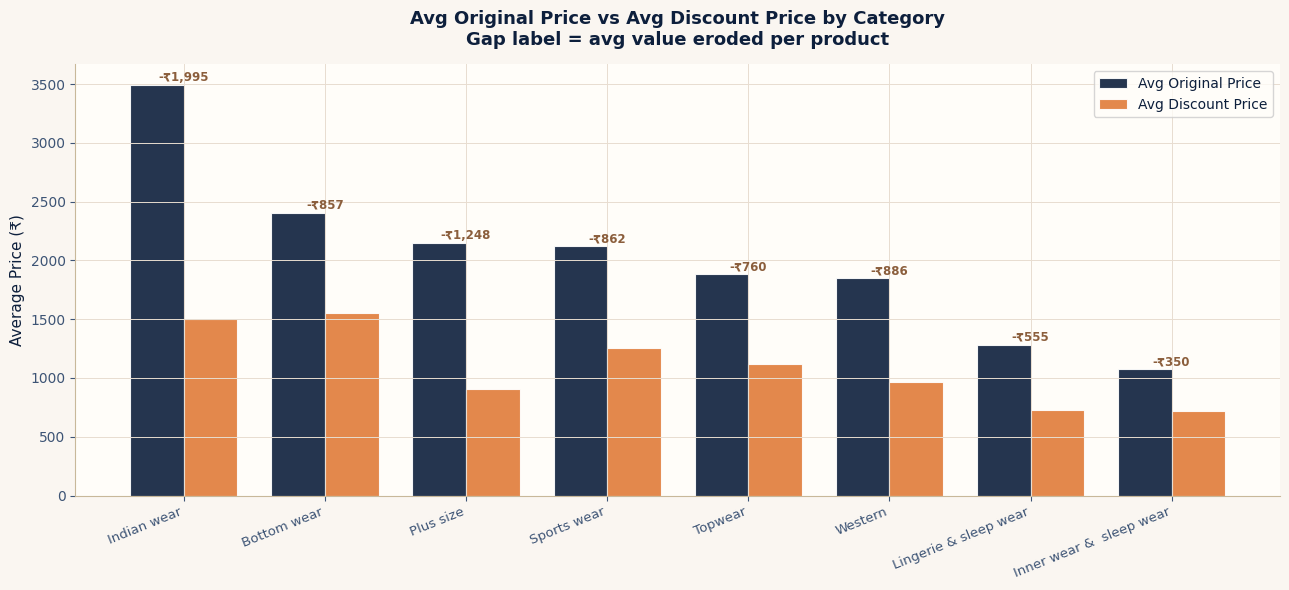

📊 Avg Price Gap by Category:
                Category  Avg_Original  Avg_Discount         Gap  Gap_%
             Indian wear   3493.553146   1498.243985 1995.309161   57.1
             Bottom wear   2407.295081   1550.373441  856.921640   35.6
               Plus size   2151.264943    903.447583 1247.817361   58.0
             Sports wear   2119.086454   1257.510945  861.575509   40.7
                 Topwear   1880.124319   1119.775747  760.348572   40.4
                 Western   1853.397192    967.204273  886.192919   47.8
   Lingerie & sleep wear   1284.659289    729.897320  554.761969   43.2
Inner wear &  sleep wear   1072.951350    722.663943  350.287407   32.6


In [24]:
cat_price = (df.groupby('Category')
               .agg(Avg_Original=('OriginalPrice','mean'),
                    Avg_Discount=('DiscountPrice','mean'))
               .sort_values('Avg_Original', ascending=False)
               .reset_index())

x     = np.arange(len(cat_price))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)

bars1 = ax.bar(x - width/2, cat_price['Avg_Original'], width,
               color=NAVY,   edgecolor='white', linewidth=0.8,
               label='Avg Original Price', alpha=0.90)
bars2 = ax.bar(x + width/2, cat_price['Avg_Discount'], width,
               color=ORANGE, edgecolor='white', linewidth=0.8,
               label='Avg Discount Price', alpha=0.90)

# Gap label (₹ value destroyed) above each pair
for i, (o, d) in enumerate(zip(cat_price['Avg_Original'], cat_price['Avg_Discount'])):
    gap = o - d
    ax.text(i, o + 30, f'-\u20b9{gap:,.0f}',
            ha='center', fontsize=8.5, fontweight='bold', color=BROWN)

ax.set_xticks(x)
ax.set_xticklabels(cat_price['Category'], rotation=22, ha='right', fontsize=9.5)
ax.set_ylabel('Average Price (\u20b9)', fontsize=11, color=NAVY)
ax.set_title('Avg Original Price vs Avg Discount Price by Category\n'
             'Gap label = avg value eroded per product',
             fontsize=13, fontweight='bold', color=NAVY, pad=14)
ax.legend(fontsize=10)
ax.set_facecolor('#FFFDF9')
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('chart_18_column_price_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\U0001f4ca Avg Price Gap by Category:")
cat_price['Gap'] = cat_price['Avg_Original'] - cat_price['Avg_Discount']
cat_price['Gap_%'] = (cat_price['Gap'] / cat_price['Avg_Original'] * 100).round(1)
print(cat_price[['Category','Avg_Original','Avg_Discount','Gap','Gap_%']].to_string(index=False))


**💡 Key Insight:** Indian Wear and Western Wear have the largest absolute price gaps — premium products being discounted the hardest.  
**✅ Decision:** These categories need discount caps — the gap is destroying aspiration value built through marketing spend.


---
## 🔹 Section 8 — Statistical Thinking Summary


In [25]:
num_cols = ['DiscountPrice','OriginalPrice','DiscountPercentage','SizeCount']
corr = df[num_cols].corr().round(3)
print("Correlation Matrix:")
print(corr)
print()
print(f"Price Skewness    : {df['DiscountPrice'].skew():.2f}  → Right-skewed")
print(f"Discount Skewness : {df['DiscountPercentage'].skew():.2f}  → Near-symmetric (peaks at 50/60%)")
print()
print("Observational Hypotheses:")
print("  H1: Higher-priced categories receive deeper absolute discounts ✔")
print("  H2: SizeCount does not predict discount depth ✔ (r≈0)")
print("  H3: Women's categories show higher price variance than Men's ✔")
print("  H4: Discount anchoring at 50% and 60% is a deliberate UX/pricing strategy ✔")


Correlation Matrix:
                    DiscountPrice  OriginalPrice  DiscountPercentage  \
DiscountPrice               1.000          0.784              -0.315   
OriginalPrice               0.784          1.000               0.206   
DiscountPercentage         -0.315          0.206               1.000   
SizeCount                   0.048         -0.003              -0.014   

                    SizeCount  
DiscountPrice           0.048  
OriginalPrice          -0.003  
DiscountPercentage     -0.014  
SizeCount               1.000  

Price Skewness    : 4.58  → Right-skewed
Discount Skewness : -0.64  → Near-symmetric (peaks at 50/60%)

Observational Hypotheses:
  H1: Higher-priced categories receive deeper absolute discounts ✔
  H2: SizeCount does not predict discount depth ✔ (r≈0)
  H3: Women's categories show higher price variance than Men's ✔
  H4: Discount anchoring at 50% and 60% is a deliberate UX/pricing strategy ✔


---
## 🔹 Section 9 — Tableau Dashboard Mapping

| Chart | Tableau Page | Purpose |
|---|---|---|
| Chart 1 — Lollipop Avg Price | Page 1 – Executive Overview | Category price ranking |
| Chart 2 — Stacked Price Segment | Page 1 – Executive Overview | Portfolio composition |
| Chart 3 — Gender Donut | Page 1 – Executive Overview | Audience split |
| Chart 4 — Histogram + KDE | Page 2 – Pricing & Discounts | Price shape & spread |
| Chart 5 — ECDF | Page 2 – Pricing & Discounts | Affordability snapshot |
| Chart 6 — Discount % Histogram | Page 2 – Pricing & Discounts | Discount anchor analysis |
| Chart 7 — Scatter + Regression | Page 2 – Pricing & Discounts | Price–discount correlation |
| Chart 8 — Correlation Heatmap | Page 2 – Pricing & Discounts | Variable relationships |
| Chart 9 — Gender×Category Heatmap | Page 1 / Page 3 | Catalogue coverage gaps |
| Chart 10 — Box + Strip | Page 2 – Pricing & Discounts | Spread & outliers |
| Chart 11 — Violin | Page 2 – Pricing & Discounts | Gender price shape |
| Chart 12 — Discount Segment | Page 2 – Pricing & Discounts | Discount mix by category |
| Chart 13 — SizeCount | Page 3 – Brand & Inventory | Inventory breadth |
| Chart 14 — Bubble Chart | Page 3 – Brand & Inventory | 3-variable category view |
| Chart 15 — Brand Dual Lollipop | Page 3 – Brand & Inventory | Brand health matrix |
| Chart 16 — Profit Erosion Chain | Page 3 – Brand & Inventory | Margin destruction flow |
| Chart 17 — Detailed Pie | Page 1 – Executive Overview | Catalogue composition by category & gender |
| Chart 18 — Column Price Gap | Page 2 – Pricing & Discounts | Original vs selling price gap |


---
## 🔹 Section 10 — Final Business Insights

> 10 insights that a real category manager or C-suite executive would act on.

1. **Myntra's discount model is structural, not cyclical.** A 42% average erosion rate is not a sale — it's the permanent business model. This conditions customers to wait for discounts, undermining full-price integrity.

2. **50% and 60% discounts appear with statistically suspicious frequency.** This is not random market behavior — it's engineered anchor pricing. Regulators and savvy consumers are increasingly aware of inflated-MRP strategies.

3. **Women's catalogue is 3× richer in category diversity than Men's.** Men's is confined to Topwear + Bottom wear + Sports. This represents Myntra's largest untapped growth vector.

4. **Indian Wear and Western Wear are priced as premium but discounted as mass-market.** This contradiction destroys the aspiration value of these categories.

5. **SizeCount has near-zero correlation with discount depth** — proving that discounting is brand- and category-policy driven, not inventory-clearance driven. This is a governance failure, not a supply problem.

6. **The ECDF confirms 50%+ of catalogue is below ₹1,000 after discounts** — a genuine affordability success that Myntra should market more aggressively.

7. **Sports Wear and Plus Size carry the heaviest high-discount burden (>60% off)** — suggesting these are acquisition categories, not margin categories. Evaluate customer LTV from these segments before continuing.

8. **Top 15 brands show a clear split: volume brands (high discount) vs. premium brands (price discipline).** Platform strategy should shift toward growing the disciplined-discount brand cohort.

9. **The Profit Erosion Waterfall shows ₹1,100 Crore+ of value destroyed daily at platform scale.** This is the single most important number for Myntra's CFO — it must drive category-specific discount governance.

10. **Men's Premium is the highest-margin opportunity on the platform.** Low competition, disciplined customers, higher AOV. A focused Men's Premium push could change the platform's margin profile within 2 years.
